# Agente autónomo de movilidad con Q-Learning
**Ejercicio Práctico – Semana 3 · Aprendizaje por Refuerzo**

####**Estudiantes.** Alexander Luna · Wilson Paredes · Alejandro Sarmiento · Diana Tandalla - Grupo 10,

Una empresa de movilidad quiere un agente capaz de desplazarse solo por una pequeña ciudad representada como una cuadrícula: debe ir de un **inicio** a un **destino**, esquivar **obstáculos**, respetar **semáforos** y minimizar el costo del recorrido. El agente se entrena con **Q-Learning tabular**.

**Contenido**

| Sección | Actividad del enunciado |
|---|---|
| 1 | Construir el entorno (cuadrícula, obstáculos, varias rutas posibles) |
| 2 | Implementar el agente (estados, acciones, recompensas, Q-Learning) |
| 3 | Encontrar la ruta (ciudad sin semáforos): trayectoria y política aprendida |
| 4 | Incorporar semáforos: esperar o tomar una ruta alternativa |
| 5 | Experimentar con hiperparámetros, exploración y función de recompensa |
| 6 | ¿La ruta aprendida es realmente la más corta? |
| 7 | Conclusiones |

> **Tiempo de ejecución:** unos 5–6 minutos con `Ejecutar todo` (la sección 5 es la más pesada). Para una prueba rápida basta con reducir `SEMILLAS` en la primera celda de código.

In [1]:
import heapq
import os
import random
import time
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from matplotlib.lines import Line2D

os.makedirs("figuras", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.width", 200)

# Cada entrenamiento se repite con varias semillas para medir la variabilidad.
# (Para una prueba rápida: SEMILLAS = [0, 1])
SEMILLAS = [0, 1, 2, 3, 4]

---
## 1. Construir el entorno

La ciudad es una cuadrícula de **10 × 10** celdas. Se define con un pequeño mapa de texto:

| Símbolo | Significado |
|---|---|
| `I` | punto de **inicio** |
| `D` | **destino** |
| `#` | **obstáculo** (edificio o calle cerrada) |
| `T` | **semáforo** (intersección controlada; sin semáforos activos se comporta como una calle normal) |
| `.` | calle transitable |

El mapa se diseñó para que existan **varias rutas de igual longitud mínima**, una **ruta alternativa más larga que evita todos los semáforos** y tres intersecciones semaforizadas sobre las rutas más cortas. Así el agente tiene una decisión real: *esperar/pasar por el semáforo* o *desviarse*.

### Modelado del entorno
* **Acciones (5):** `↑`, `↓`, `←`, `→` y `esperar`.
* **Semáforos:** cada uno sigue un ciclo de **6 pasos: 3 en verde y 3 en rojo**, con *desfases* distintos (0, 2 y 4) para que no estén sincronizados. El color en el instante `t` es verde si `(t + desfase) mod 6 < 3`.
* **Estado del agente:** `(fila, columna, fase)`, donde `fase = t mod 6` es la posición dentro del ciclo. Conocer la fase equivale a conocer el color actual (y futuro) de todos los semáforos. Sin semáforos, el estado es solo `(fila, columna)`.
* **Recompensas:** `−1` por cada paso (incluye esperar) · `−5` adicional si choca con un obstáculo o el borde (no se mueve) · `−20` adicional (multa) si entra a un semáforo en rojo · `+100` al llegar al destino.
* **Episodio:** empieza en el inicio con una **fase aleatoria** (para que el agente aprenda a actuar en cualquier momento del ciclo) y termina al llegar al destino o a los 200 pasos.

In [2]:
MAPA = """
I . . . . . . T . .
# . # # . . . . # .
. # # . . . # . # #
. . . . . # . . . .
. . . . # . # # T .
. # # . . . . . . .
. . . . . . . . . #
. . . . . . # . T #
. # . # # # # . . .
# . . # . . . . # D
"""

ACCIONES = ["↑", "↓", "←", "→", "esperar"]
DELTAS = [(-1, 0), (1, 0), (0, -1), (0, 1), (0, 0)]
ESPERAR = 4


class EntornoCiudad:
    """Cuadrícula tipo ciudad con obstáculos y (opcionalmente) semáforos cíclicos."""

    def __init__(self, mapa=MAPA, con_semaforos=True, periodo=6, verde=3, desfases=(0, 2, 4),
                 ve_semaforos=True, r_paso=-1.0, r_choque=-5.0, r_rojo=-20.0, r_meta=100.0,
                 max_pasos=200):
        filas = [f.split() for f in mapa.strip().splitlines()]
        self.N, self.M = len(filas), len(filas[0])
        self.obstaculos, semaforos = set(), []
        for i, fila in enumerate(filas):
            for j, ch in enumerate(fila):
                if ch == "#": self.obstaculos.add((i, j))
                elif ch == "I": self.inicio = (i, j)
                elif ch == "D": self.meta = (i, j)
                elif ch == "T": semaforos.append((i, j))
        self.semaforos_mapa = semaforos                       # posiciones (aunque estén apagados)
        self.con_semaforos = con_semaforos
        self.semaforos = dict(zip(semaforos, desfases)) if con_semaforos else {}
        self.periodo, self.verde = periodo, verde
        # Si el agente "no ve" los semáforos, su estado omite la fase (agente ciego).
        self.n_fases = periodo if (con_semaforos and ve_semaforos) else 1
        self.r_paso, self.r_choque, self.r_rojo, self.r_meta = r_paso, r_choque, r_rojo, r_meta
        self.max_pasos = max_pasos
        self.n_acciones = len(ACCIONES)
        self.n_estados = self.N * self.M * self.n_fases

    # ---- semáforos ----
    def es_rojo(self, celda, t):
        d = self.semaforos.get(celda)
        return d is not None and ((t + d) % self.periodo) >= self.verde

    # ---- codificación del estado ----
    def estado(self):
        fase = (self.t % self.periodo) if self.n_fases > 1 else 0
        return (self.pos[0] * self.M + self.pos[1]) * self.n_fases + fase

    # ---- dinámica ----
    def reset(self, fase_inicial=None, rng=random):
        self.pos, self.pasos = self.inicio, 0
        self.t = rng.randrange(self.periodo) if fase_inicial is None else fase_inicial
        return self.estado()

    def step(self, a):
        r, c = self.pos
        dr, dc = DELTAS[a]
        nr, nc = r + dr, c + dc
        recompensa, choque, rojo = self.r_paso, False, False
        if a != ESPERAR:
            if not (0 <= nr < self.N and 0 <= nc < self.M) or (nr, nc) in self.obstaculos:
                nr, nc = r, c                                 # choque: no se mueve
                recompensa += self.r_choque
                choque = True
            elif self.es_rojo((nr, nc), self.t):              # entra a un semáforo en rojo: multa
                recompensa += self.r_rojo
                rojo = True
        self.pos = (nr, nc)
        self.t += 1
        self.pasos += 1
        terminado = self.pos == self.meta
        if terminado:
            recompensa += self.r_meta
        truncado = (not terminado) and self.pasos >= self.max_pasos
        return self.estado(), recompensa, terminado, truncado, {"choque": choque, "rojo": rojo}


env_sin = EntornoCiudad(con_semaforos=False)     # ciudad sin semáforos
env = EntornoCiudad(con_semaforos=True)          # ciudad con semáforos
print(f"Cuadrícula {env.N}x{env.M} | inicio {env.inicio} | destino {env.meta} | "
      f"{len(env.obstaculos)} obstáculos | semáforos en {env.semaforos_mapa}")
print(f"Estados: {env_sin.n_estados} sin semáforos, {env.n_estados} con semáforos | acciones: {env.n_acciones}")

Cuadrícula 10x10 | inicio (0, 0) | destino (9, 9) | 26 obstáculos | semáforos en [(0, 7), (4, 8), (7, 8)]
Estados: 100 sin semáforos, 600 con semáforos | acciones: 5


### Visualización de la ciudad
Funciones para dibujar la cuadrícula, rutas (con flechas y esperas) y la política aprendida.

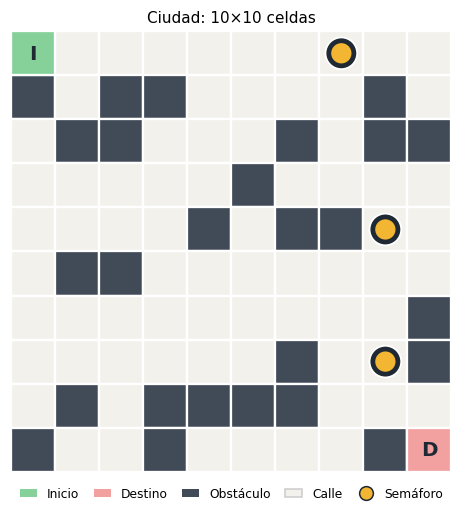

In [3]:
COLORES = dict(calle="#F3F1EC", obstaculo="#414A57", inicio="#86D19A", meta="#F2A0A0",
               ambar="#F2B632", verde="#2E9E4F", rojo="#D64545")


def _centro(celda, d=0.0):
    return celda[1] + 0.5 + d, celda[0] + 0.5 + d


def dibujar_ciudad(env, ax, rutas=(), titulo="", colores_semaforo=None, valores=None):
    """Dibuja la cuadrícula.
    rutas: lista de dicts {ruta, color, estilo, fondo}. Con fondo=True la ruta es una franja translúcida (sin flechas).
    colores_semaforo: {celda: color} (por defecto ámbar).  valores: matriz N×M para pintar un mapa de calor."""
    ax.set_xlim(0, env.M); ax.set_ylim(env.N, 0); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    if valores is not None:
        lo, hi = np.nanmin(valores), np.nanmax(valores)
        vmin = lo - 0.25 * (hi - lo)
    for i in range(env.N):
        for j in range(env.M):
            if (i, j) in env.obstaculos:
                col = COLORES["obstaculo"]
            elif valores is not None and not np.isnan(valores[i, j]):
                col = plt.cm.YlGn((valores[i, j] - vmin) / max(hi - vmin, 1e-9))
            else:
                col = COLORES["calle"]
            ax.add_patch(Rectangle((j, i), 1, 1, facecolor=col, edgecolor="white", lw=1.5))
    for celda, txt, col in [(env.inicio, "I", COLORES["inicio"]), (env.meta, "D", COLORES["meta"])]:
        ax.add_patch(Rectangle((celda[1], celda[0]), 1, 1, facecolor=col, edgecolor="white", lw=1.5))
        ax.text(*_centro(celda), txt, ha="center", va="center", fontsize=13, fontweight="bold",
                color="#1F2933", zorder=10)
    if env.con_semaforos:                                        # sin semáforos activos no se dibujan
        for celda in env.semaforos_mapa:
            c = (colores_semaforo or {}).get(celda, COLORES["ambar"])
            ax.add_patch(Circle(_centro(celda), 0.36, facecolor="#1F2933", edgecolor="white", lw=1.2, zorder=3))
            ax.add_patch(Circle(_centro(celda), 0.23, facecolor=c, edgecolor="none", zorder=4))
    for r in [r for r in rutas if r.get("fondo")]:               # franjas translúcidas: más oscuro = más rutas comparten el tramo
        xs, ys = zip(*[_centro(c) for c in r["ruta"]])
        ax.plot(xs, ys, color=r.get("color", "#999999"), lw=6, alpha=0.30, solid_capstyle="round",
                solid_joinstyle="round", zorder=2)
    normales = [r for r in rutas if not r.get("fondo")]
    for k, r in enumerate(normales):
        d = (k - (len(normales) - 1) / 2) * 0.10                 # pequeño desplazamiento para no superponer rutas
        color, ls = r.get("color", "#1f77b4"), r.get("estilo", "-")
        esperas = {}
        for a, b in zip(r["ruta"][:-1], r["ruta"][1:]):
            if a == b:
                esperas[a] = esperas.get(a, 0) + 1
                continue
            ax.annotate("", xy=_centro(b, d), xytext=_centro(a, d), zorder=6,
                        arrowprops=dict(arrowstyle="-|>", color=color, lw=2.2, mutation_scale=9,
                                        linestyle=ls, shrinkA=0, shrinkB=0))
        for celda, n in esperas.items():
            x, y = _centro(celda, d)
            ax.text(x, y - 0.33, f"espera ×{n}", ha="center", va="center", fontsize=6.5, zorder=8,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=color, lw=0.8))
    ax.set_title(titulo, fontsize=10, pad=6)


def leyenda_mapa(ax, extra=(), con_semaforos=True):
    h = [Rectangle((0, 0), 1, 1, fc=COLORES["inicio"]), Rectangle((0, 0), 1, 1, fc=COLORES["meta"]),
         Rectangle((0, 0), 1, 1, fc=COLORES["obstaculo"]), Rectangle((0, 0), 1, 1, fc=COLORES["calle"], ec="#ccc")]
    t = ["Inicio", "Destino", "Obstáculo", "Calle"]
    if con_semaforos:
        h.append(Line2D([0], [0], marker="o", color="w", mfc=COLORES["ambar"], mec="#1F2933", ms=9)); t.append("Semáforo")
    for etiqueta, color in extra:
        h.append(Line2D([0], [0], color=color, lw=2.2)); t.append(etiqueta)
    ax.legend(h, t, loc="upper center", bbox_to_anchor=(0.5, -0.01), ncol=4 if extra else 5,
              frameon=False, fontsize=8, handlelength=1.4, columnspacing=1.2)


def colores_al_cruzar(env, r):
    """Color con que el agente encontró cada semáforo que cruzó (ámbar = no lo cruzó en este recorrido)."""
    col = {}
    for k, (a, b) in enumerate(zip(r["ruta"][:-1], r["ruta"][1:])):
        if a != b and b in env.semaforos:
            col[b] = COLORES["rojo" if env.es_rojo(b, r["fase0"] + k) else "verde"]
    return col


def dibujar_valores(env, Q, visitas, ax, titulo=""):
    """Mapa de calor del valor de cada celda: máx Q(s,·) entre las acciones que el agente llegó a probar."""
    V = np.full((env.N, env.M), np.nan)
    for i in range(env.N):
        for j in range(env.M):
            s0 = (i * env.M + j) * env.n_fases
            probadas = visitas[s0:s0 + env.n_fases] > 0            # acciones probadas alguna vez
            if (i, j) not in env.obstaculos and (i, j) != env.meta and probadas.any():
                V[i, j] = Q[s0:s0 + env.n_fases][probadas].max()
    dibujar_ciudad(env, ax, titulo=titulo, valores=V)
    lo, hi = np.nanmin(V), np.nanmax(V)
    sm = plt.cm.ScalarMappable(cmap=plt.cm.YlGn, norm=plt.Normalize(lo - 0.25 * (hi - lo), hi))
    plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.02).set_label("Valor de la celda: máx Q(s,·)", fontsize=8)


SIMBOLO = ["↑", "↓", "←", "→", "○"]                                # ○ = esperar


def acciones_por_celda(env, Q):
    """Acciones greedy que el agente ejecuta en cada celda al conducir desde cada fase inicial."""
    dec = {}
    for f in range(env.periodo if env.con_semaforos else 1):
        r = rollout(env, Q, f)
        for k, (celda, a) in enumerate(zip(r["ruta"][:-1], r["acciones"])):
            dec.setdefault(celda, {})[(f + k) % env.periodo] = a
    return dec


def dibujar_decisiones(env, Q, ax, titulo=""):
    """Mapa de decisiones: flecha azul = misma acción sin importar la fase; celda naranja = depende de la fase."""
    dibujar_ciudad(env, ax, titulo=titulo)
    for celda, por_fase in acciones_por_celda(env, Q).items():
        acts = sorted(set(por_fase.values())); x, y = _centro(celda)
        if len(acts) == 1:
            a = acts[0]
            if a == ESPERAR:
                ax.plot(x, y, "o", ms=8, mfc="none", mec="#7A1F5C", mew=2, zorder=7)
            else:
                dr, dc = DELTAS[a]
                ax.annotate("", xy=(x + dc * 0.33, y + dr * 0.33), xytext=(x - dc * 0.33, y - dr * 0.33), zorder=7,
                            arrowprops=dict(arrowstyle="-|>", color="#1F5FA8", lw=2, mutation_scale=10))
        else:
            ax.add_patch(Rectangle((celda[1], celda[0]), 1, 1, fc="#F8D9A0", ec="white", lw=1.5, zorder=2))
            ax.text(x, y, " ".join(SIMBOLO[a] for a in acts), ha="center", va="center", fontsize=10,
                    color="#7A3E00", fontweight="bold", zorder=8)
    ax.set_xlabel("Flecha azul: misma acción en cualquier fase · celda naranja: la acción depende de la fase (○ = esperar)",
                  fontsize=7.5)


fig, ax = plt.subplots(figsize=(5.2, 5.2))
dibujar_ciudad(env, ax, titulo="Ciudad: 10×10 celdas")
leyenda_mapa(ax)
plt.savefig("figuras/fig_mapa.png", bbox_inches="tight"); plt.show()

### Rutas posibles
Antes de aprender nada, calculamos con **búsqueda en anchura (BFS)** cuántas rutas de longitud mínima existen (ignorando los semáforos) y cuál es la mejor ruta que evita todos los semáforos. Esto servirá de referencia para juzgar al agente.

Ruta más corta (ignorando semáforos): 18 pasos | rutas distintas con esa longitud: 4
Ruta más corta que evita TODOS los semáforos: 20 pasos (+2)
  Ruta corta 1: cruza 2 semáforo(s) [(4, 8), (7, 8)]
  Ruta corta 2: cruza 2 semáforo(s) [(4, 8), (7, 8)]
  Ruta corta 3: cruza 2 semáforo(s) [(4, 8), (7, 8)]
  Ruta corta 4: cruza 3 semáforo(s) [(0, 7), (4, 8), (7, 8)]


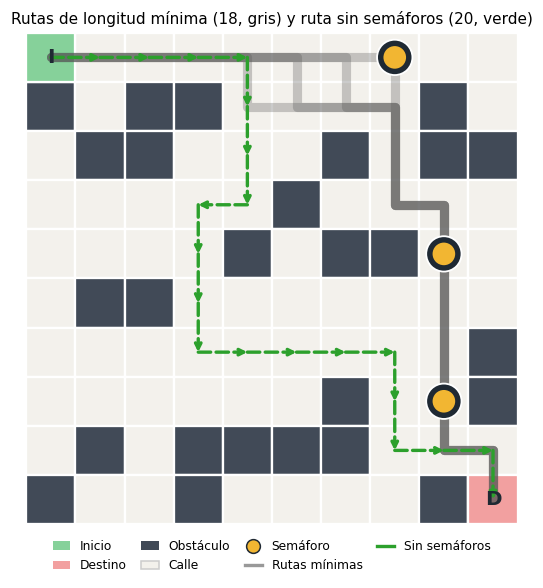

In [4]:
def distancias(env, origen, evitar=()):
    dist, q = {origen: 0}, deque([origen])
    while q:
        u = q.popleft()
        for dr, dc in DELTAS[:4]:
            v = (u[0] + dr, u[1] + dc)
            if 0 <= v[0] < env.N and 0 <= v[1] < env.M and v not in env.obstaculos \
                    and v not in evitar and v not in dist:
                dist[v] = dist[u] + 1; q.append(v)
    return dist


def rutas_minimas(env, evitar=()):
    """Todas las rutas de longitud mínima inicio→destino (en número de celdas)."""
    dS, dG = distancias(env, env.inicio, evitar), distancias(env, env.meta, evitar)
    L, rutas = dS[env.meta], []
    def dfs(u, cam):
        if u == env.meta: rutas.append(cam); return
        for dr, dc in DELTAS[:4]:
            v = (u[0] + dr, u[1] + dc)
            if v in dS and dS[v] == dS[u] + 1 and dS[v] + dG[v] == L: dfs(v, cam + [v])
    dfs(env.inicio, [env.inicio])
    return L, rutas


L_min, rutas_cortas = rutas_minimas(env_sin)
L_libre, rutas_libres = rutas_minimas(env, evitar=set(env.semaforos_mapa))
print(f"Ruta más corta (ignorando semáforos): {L_min} pasos | rutas distintas con esa longitud: {len(rutas_cortas)}")
print(f"Ruta más corta que evita TODOS los semáforos: {L_libre} pasos (+{L_libre - L_min})")
for k, r in enumerate(rutas_cortas, 1):
    cruza = [c for c in r if c in env.semaforos_mapa]
    print(f"  Ruta corta {k}: cruza {len(cruza)} semáforo(s) {cruza}")

rutas_dib = [dict(ruta=r, color="#555555", fondo=True) for r in rutas_cortas]      # franjas: más oscuro = tramo compartido
rutas_dib.append(dict(ruta=rutas_libres[0], color="#2CA02C", estilo="--"))
fig, ax = plt.subplots(figsize=(5.8, 5.8))
dibujar_ciudad(env, ax, rutas_dib, titulo=f"Rutas de longitud mínima ({L_min}, gris) y ruta sin semáforos ({L_libre}, verde)")
leyenda_mapa(ax, extra=[("Rutas mínimas", "#999999"), ("Sin semáforos", "#2CA02C")]); plt.show()

---
## 2. Implementar el agente (Q-Learning)

El agente mantiene una **tabla Q** de tamaño `(estados × acciones)` y la actualiza tras cada paso con la regla de Q-Learning:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \Big[\, r + \gamma \max_{a'} Q(s',a') - Q(s,a) \,\Big]$$

* **Política de exploración ε-greedy:** con probabilidad ε elige una acción al azar; con probabilidad 1−ε, la de mayor Q. ε decae de 1.0 a 0.05.
* **Inicialización optimista (`Q0 = 100`):** todas las acciones empiezan con un valor alto, de modo que el agente prueba sistemáticamente lo que aún no conoce. En la sección 5 se compara con `Q0 = 0` y se justifica esta elección.
* **Hiperparámetros base:** `α = 0.1`, `γ = 0.99`, 10 000 episodios.

Además de `entrenar`, se definen utilidades para **seguir la política greedy** (`rollout`), evaluarla desde cada fase inicial del ciclo y calcular el **óptimo exacto** con Dijkstra sobre el grafo tiempo-expandido `(celda, fase)` (se usa en las secciones 4 y 6 como referencia).

In [5]:
CONFIG_BASE = dict(episodios=10_000, alpha=0.1, gamma=0.99, eps_ini=1.0, eps_fin=0.05,
                   eps_decay=0.9995, q_ini=100.0)


def entrenar(env, episodios=10_000, alpha=0.1, gamma=0.99, eps_ini=1.0, eps_fin=0.05,
             eps_decay=0.9995, q_ini=100.0, semilla=0, eval_cada=100):
    """Q-Learning tabular con política ε-greedy (ε decae exponencialmente por episodio)."""
    rng = random.Random(semilla)
    Q = np.full((env.n_estados, env.n_acciones), float(q_ini))
    visitas = np.zeros((env.n_estados, env.n_acciones), dtype=int)   # veces que se probó cada (estado, acción)
    hist = dict(retorno=[], pasos=[], multas=[], exito=[], eval_ep=[], eval_ret=[])
    for ep in range(episodios):
        eps = max(eps_fin, eps_ini * eps_decay ** ep)
        s = env.reset(rng=rng)                                   # fase inicial aleatoria
        ret, multas = 0.0, 0
        while True:
            if rng.random() < eps:
                a = rng.randrange(env.n_acciones)                # explorar
            else:
                q = Q[s]
                a = rng.choice(np.flatnonzero(q == q.max()))     # explotar (desempate al azar)
            s2, r, terminado, truncado, info = env.step(a)
            objetivo = r if terminado else r + gamma * Q[s2].max()
            Q[s, a] += alpha * (objetivo - Q[s, a])              # actualización de Q-Learning
            visitas[s, a] += 1
            ret += r; multas += info["rojo"]
            s = s2
            if terminado or truncado: break
        hist["retorno"].append(ret); hist["pasos"].append(env.pasos)
        hist["multas"].append(multas); hist["exito"].append(terminado)
        if eval_cada and (ep % eval_cada == 0 or ep == episodios - 1):
            hist["eval_ep"].append(ep)
            hist["eval_ret"].append(np.mean([x["retorno"] for x in evaluar_politica(env, Q)]))
    hist["visitas"] = visitas
    return Q, hist


def rollout(env, Q, fase0):
    """Recorre el entorno siguiendo la política greedy (sin exploración)."""
    s = env.reset(fase_inicial=fase0)
    ruta, acciones, ret, multas, choques = [env.pos], [], 0.0, 0, 0
    for _ in range(env.max_pasos):
        a = int(np.argmax(Q[s]))
        s, r, terminado, truncado, info = env.step(a)
        ret += r; multas += info["rojo"]; choques += info["choque"]
        acciones.append(a); ruta.append(env.pos)
        if terminado or truncado: break
    return dict(fase0=fase0, ruta=ruta, acciones=acciones, retorno=ret, pasos=len(acciones),
                esperas=acciones.count(ESPERAR), multas=multas, choques=choques,
                exito=env.pos == env.meta)


def evaluar_politica(env, Q):
    """Política greedy desde cada fase inicial posible del ciclo de semáforos."""
    return [rollout(env, Q, f) for f in range(env.periodo if env.con_semaforos else 1)]


def ruta_optima(env, fase0, modo="libre"):
    """Óptimo exacto (Dijkstra sobre (celda, fase, usó_semáforo)).
    modo: 'libre'  -> cualquier ruta;  'evitar' -> prohibido entrar a semáforos;
          'usar'   -> debe cruzar al menos un semáforo."""
    P = env.periodo if env.con_semaforos else 1
    ini = (env.inicio, fase0 % P, False)
    dist, prev, cnt = {ini: 0.0}, {}, 0
    pq, fin = [(0.0, 0, ini)], None
    while pq:
        d, _, u = heapq.heappop(pq)
        if d > dist[u]: continue
        if u[0] == env.meta and (modo != "usar" or u[2]):
            fin = u; break
        for a, (dr, dc) in enumerate(DELTAS):
            nr, nc = u[0][0] + dr, u[0][1] + dc
            costo = -env.r_paso
            if a != ESPERAR:
                if not (0 <= nr < env.N and 0 <= nc < env.M) or (nr, nc) in env.obstaculos: continue
                if (nr, nc) in env.semaforos and modo == "evitar": continue
                if env.es_rojo((nr, nc), u[1]): costo += -env.r_rojo
            v = ((nr, nc), (u[1] + 1) % P, u[2] or (nr, nc) in env.semaforos)
            if d + costo < dist.get(v, 1e18):
                dist[v], prev[v] = d + costo, (u, a); cnt += 1
                heapq.heappush(pq, (d + costo, cnt, v))
    if fin is None: return None
    cam, acc, v = [fin[0]], [], fin
    while v != ini:
        u, a = prev[v]; acc.append(a); cam.append(u[0]); v = u
    return dict(retorno=env.r_meta - dist[fin], ruta=cam[::-1], acciones=acc[::-1],
                pasos=len(acc), esperas=acc.count(ESPERAR))


def retornos_optimos(env):
    return [ruta_optima(env, f)["retorno"] for f in range(env.periodo if env.con_semaforos else 1)]

---
## 3. Encontrar la ruta (ciudad sin semáforos)

Primero se entrena el agente en la ciudad **sin semáforos**: el estado es solo la posición (100 estados). Se entrena con 5 semillas para medir la variabilidad; la semilla 0 se usa para mostrar la ruta y la política.

In [6]:
def entrenar_multi(env, config, semillas=SEMILLAS):
    t0 = time.time()
    res = [entrenar(env, semilla=s, **config) for s in semillas]
    print(f"   {len(semillas)} entrenamientos en {time.time() - t0:.0f} s")
    return [r[0] for r in res], [r[1] for r in res]


print("Entrenando en la ciudad SIN semáforos...")
Qs_sin, hists_sin = entrenar_multi(env_sin, CONFIG_BASE)
opt_sin = retornos_optimos(env_sin)[0]

res = rollout(env_sin, Qs_sin[0], 0)
print(f"\nRuta greedy aprendida: {res['pasos']} pasos | retorno {res['retorno']:.0f} | "
      f"esperas {res['esperas']} | choques {res['choques']} | ¿llegó? {res['exito']}")
print(f"Ruta mínima según BFS: {L_min} pasos → retorno óptimo {opt_sin:.0f}")
print("¿La ruta aprendida es una de las rutas mínimas?", res["ruta"] in rutas_cortas)
print("Pasos de la ruta greedy en cada una de las 5 semillas:", [evaluar_politica(env_sin, Q)[0]["pasos"] for Q in Qs_sin])

Entrenando en la ciudad SIN semáforos...
   5 entrenamientos en 30 s

Ruta greedy aprendida: 18 pasos | retorno 82 | esperas 0 | choques 0 | ¿llegó? True
Ruta mínima según BFS: 18 pasos → retorno óptimo 82
¿La ruta aprendida es una de las rutas mínimas? True
Pasos de la ruta greedy en cada una de las 5 semillas: [18, 18, 18, 18, 18]


### Evolución de la recompensa durante el entrenamiento
La recompensa por episodio (media móvil de 200 episodios, promedio de las 5 semillas) parte muy negativa —el agente choca y deambula hasta agotar los 200 pasos— y converge hacia el óptimo a medida que ε decae y la tabla Q se ajusta. La curva naranja evalúa la política *greedy* (sin exploración) cada 100 episodios.

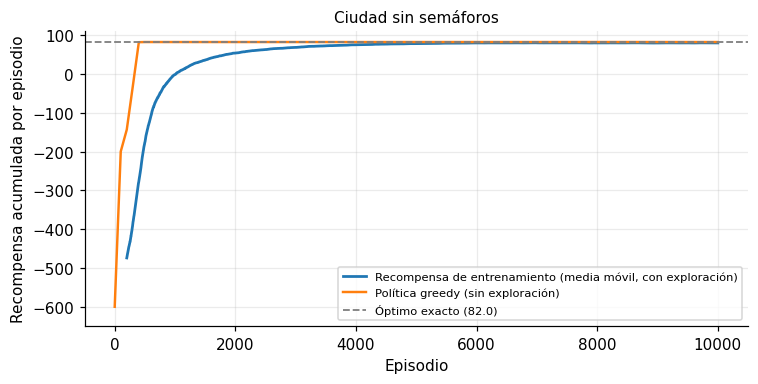

In [7]:
def suavizar(x, w=200):
    c = np.cumsum(np.insert(np.asarray(x, float), 0, 0))
    return (c[w:] - c[:-w]) / w


def graficar_curvas(ax, hists, titulo, optimo, w=200, leyenda=True):
    curvas = np.array([suavizar(h["retorno"], w) for h in hists])
    x = np.arange(w, len(hists[0]["retorno"]) + 1)
    m, s = curvas.mean(0), curvas.std(0)
    ax.plot(x, m, color="#1F77B4", lw=1.8, label="Recompensa de entrenamiento (media móvil, con exploración)")
    ax.fill_between(x, m - s, m + s, color="#1F77B4", alpha=0.18, lw=0)
    ev = np.array([h["eval_ret"] for h in hists]).mean(0)
    ax.plot(hists[0]["eval_ep"], ev, color="#FF7F0E", lw=1.6, label="Política greedy (sin exploración)")
    ax.axhline(optimo, color="gray", ls="--", lw=1.2, label=f"Óptimo exacto ({optimo:.1f})")
    ax.set_ylim(-650, 110); ax.set_xlabel("Episodio"); ax.set_ylabel("Recompensa acumulada por episodio")
    ax.set_title(titulo, fontsize=10); ax.grid(alpha=0.25)
    if leyenda: ax.legend(fontsize=7.5, loc="lower right", frameon=True)


fig, ax = plt.subplots(figsize=(7, 3.6))
graficar_curvas(ax, hists_sin, "Ciudad sin semáforos", opt_sin)
plt.tight_layout(); plt.savefig("figuras/fig_recompensa_sin.png", bbox_inches="tight"); plt.show()

### Ruta aprendida y política
A la izquierda, la ruta greedy del agente (azul) sobre las rutas mínimas posibles (franjas grises; más oscuro = tramo que comparten). A la derecha, el **valor aprendido de cada celda** (máx Q): cuanto más verde, más “cerca” del destino en términos de recompensa. Las celdas sin color nunca se probaron.

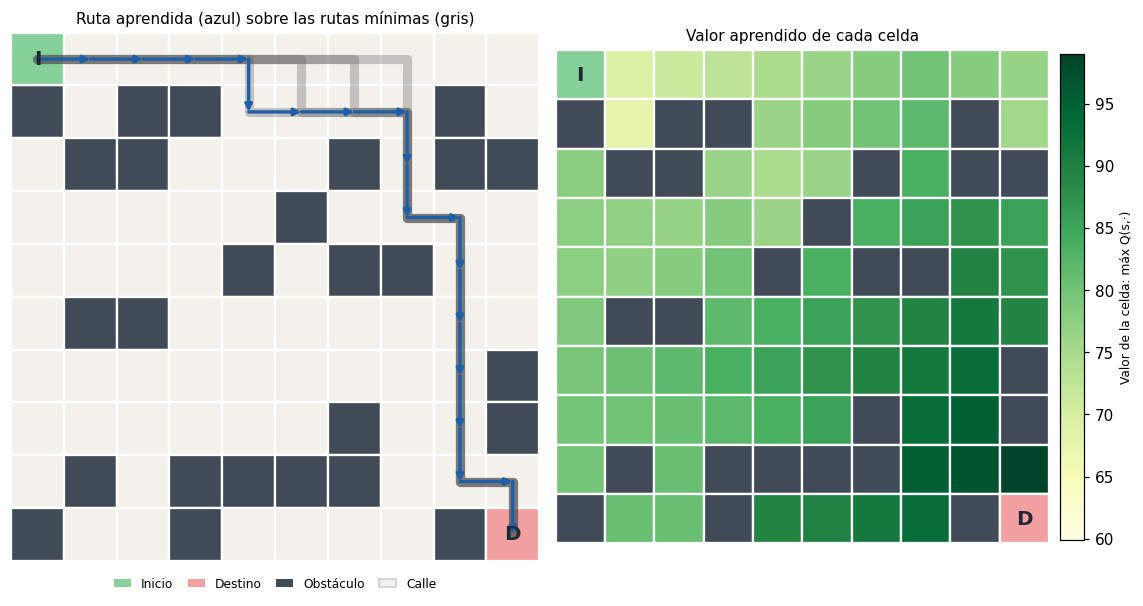

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10.5, 5.4))
dibujar_ciudad(env_sin, axs[0], [dict(ruta=r, color="#555555", fondo=True) for r in rutas_cortas]
               + [dict(ruta=res["ruta"], color="#1F5FA8")], "Ruta aprendida (azul) sobre las rutas mínimas (gris)")
leyenda_mapa(axs[0], con_semaforos=False)
dibujar_valores(env_sin, Qs_sin[0], hists_sin[0]["visitas"], axs[1], "Valor aprendido de cada celda")
plt.tight_layout(); plt.savefig("figuras/fig_ruta_sin_semaforos.png", bbox_inches="tight"); plt.show()

**Lectura.** Sin semáforos el agente encuentra una de las rutas de longitud mínima (18 pasos, retorno 82 = 100 − 18) sin chocar, y lo logra en las 5 semillas. En el mapa de valores se ve cómo la recompensa del destino se “propaga hacia atrás”: las celdas que están sobre las rutas mínimas y cerca del destino tienen los valores más altos, y el valor va bajando (≈ −1 por paso, ajustado por γ) a medida que la celda está más lejos. Así el agente puede elegir en cada celda el vecino de mayor valor, que es exactamente seguir la ruta corta.

---
## 4. Incorporar semáforos

Ahora la ciudad tiene **3 semáforos** cíclicos. Vamos paso a paso.

### Paso 4.1 · Ver cómo cambian los semáforos
Cada semáforo repite un ciclo de 6 instantes (3 verde, 3 rojo) pero con un **desfase** distinto. Por eso, cuando uno está en verde, otro puede estar en rojo. Cada fila es un instante del ciclo (`t mod 6`).

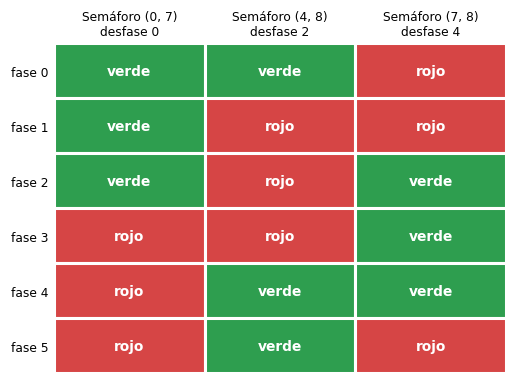

In [9]:
def dibujar_ciclo(env, ax):
    n = len(env.semaforos_mapa)
    for f in range(env.periodo):
        for k, c in enumerate(env.semaforos_mapa):
            rojo = env.es_rojo(c, f)
            ax.add_patch(Rectangle((k, f), 1, 1, fc=COLORES["rojo" if rojo else "verde"], ec="white", lw=2))
            ax.text(k + 0.5, f + 0.5, "rojo" if rojo else "verde", ha="center", va="center",
                    color="white", fontsize=9, fontweight="bold")
    ax.set_xlim(0, n); ax.set_ylim(env.periodo, 0)
    ax.set_xticks([k + 0.5 for k in range(n)])
    ax.set_xticklabels([f"Semáforo {c}\ndesfase {env.semaforos[c]}" for c in env.semaforos_mapa], fontsize=8)
    ax.set_yticks([f + 0.5 for f in range(env.periodo)])
    ax.set_yticklabels([f"fase {f}" for f in range(env.periodo)], fontsize=8)
    ax.xaxis.tick_top(); ax.tick_params(length=0)
    for sp in ax.spines.values(): sp.set_visible(False)


fig, ax = plt.subplots(figsize=(4.8, 3.6))
dibujar_ciclo(env, ax)
plt.tight_layout(); plt.savefig("figuras/fig_ciclo_semaforos.png", bbox_inches="tight"); plt.show()

**Lectura.** En la fase 0, por ejemplo, el semáforo (0,7) está en verde, el (4,8) en rojo y el (7,8) en verde. Como los desfases son distintos, el mejor momento para salir cambia con la fase: eso es lo que el agente tiene que aprender.

### Paso 4.2 · ¿Por qué el estado incluye la fase?
Si el estado fuera solo `(fila, columna)`, dos situaciones idénticas en el mapa (llegar a un semáforo en verde o en rojo) se verían igual y el agente no podría distinguirlas: violaría la *propiedad de Markov*. Al añadir `fase = t mod 6`, el color de **todos** los semáforos queda determinado por el estado. Más adelante (sección 5) medimos cuánto se pierde si se le quita esa información.

### Paso 4.3 · Una actualización de Q-Learning, con números reales
Antes de entrenar miles de episodios, veamos **una sola** actualización, para entender qué hace la fórmula. Usamos una tabla Q recién creada (todo en 100, inicialización optimista) y dos situaciones: un paso normal y un paso que entra a un semáforo en rojo.

In [10]:
def anatomia_de_una_actualizacion(env, Q, celda, t, accion, alpha=0.1, gamma=0.99):
    env.reset(fase_inicial=t); env.pos = celda                 # colocamos al agente en la situación elegida
    s = env.estado()
    s2, r, terminado, _, info = env.step(accion)
    q_viejo, q_sig = Q[s, accion], Q[s2].max()
    objetivo = r if terminado else r + gamma * q_sig
    error = objetivo - q_viejo
    destino = (celda[0] + DELTAS[accion][0], celda[1] + DELTAS[accion][1])
    print(f"SITUACIÓN: el agente está en {celda} en el instante t={t} y elige '{ACCIONES[accion]}' hacia {destino}")
    if destino in env.semaforos:
        print(f"   (el semáforo {destino} está en {'ROJO' if info['rojo'] else 'VERDE'} en ese instante)")
    print(f"  1) Recompensa recibida:        r = {r:+.0f}" + ("   (−1 por paso y −20 de multa)" if info["rojo"] else "   (−1 por paso)"))
    print(f"  2) Mejor valor desde s':       máx Q(s', ·) = {q_sig:.2f}")
    print(f"  3) Objetivo (lo que 'deberíamos' valer): r + γ·máx Q(s',·) = {r:+.0f} + {gamma}·{q_sig:.0f} = {objetivo:.2f}")
    print(f"  4) Error TD = objetivo − Q(s,a) = {objetivo:.2f} − {q_viejo:.2f} = {error:+.2f}")
    print(f"  5) Q nuevo = Q + α·error       = {q_viejo:.2f} + {alpha}·({error:+.2f}) = {q_viejo + alpha * error:.2f}\n")


Q_demo = np.full((env.n_estados, env.n_acciones), CONFIG_BASE["q_ini"])
anatomia_de_una_actualizacion(env, Q_demo, celda=(0, 0), t=0, accion=3)     # paso normal hacia la derecha
anatomia_de_una_actualizacion(env, Q_demo, celda=(0, 6), t=3, accion=3)     # entra al semáforo (0,7) en rojo

SITUACIÓN: el agente está en (0, 0) en el instante t=0 y elige '→' hacia (0, 1)
  1) Recompensa recibida:        r = -1   (−1 por paso)
  2) Mejor valor desde s':       máx Q(s', ·) = 100.00
  3) Objetivo (lo que 'deberíamos' valer): r + γ·máx Q(s',·) = -1 + 0.99·100 = 98.00
  4) Error TD = objetivo − Q(s,a) = 98.00 − 100.00 = -2.00
  5) Q nuevo = Q + α·error       = 100.00 + 0.1·(-2.00) = 99.80

SITUACIÓN: el agente está en (0, 6) en el instante t=3 y elige '→' hacia (0, 7)
   (el semáforo (0, 7) está en ROJO en ese instante)
  1) Recompensa recibida:        r = -21   (−1 por paso y −20 de multa)
  2) Mejor valor desde s':       máx Q(s', ·) = 100.00
  3) Objetivo (lo que 'deberíamos' valer): r + γ·máx Q(s',·) = -21 + 0.99·100 = 78.00
  4) Error TD = objetivo − Q(s,a) = 78.00 − 100.00 = -22.00
  5) Q nuevo = Q + α·error       = 100.00 + 0.1·(-22.00) = 97.80



**Lectura.** Con la inicialización optimista, cada acción que el agente prueba *baja* un poco su valor (99.8 en el paso normal). La acción que entra en rojo baja mucho más (97.8): la multa hace que esa acción se vuelva menos atractiva que las acciones aún no probadas. Repetido miles de veces, ese mecanismo hace que el agente aprenda a esperar o a desviarse.

### Paso 4.4 · Entrenar al agente con semáforos
Mismos hiperparámetros base, ahora en la ciudad con semáforos (600 estados). Se entrena con 5 semillas y se calcula el **óptimo exacto** por fase como referencia.

In [11]:
print("Entrenando en la ciudad CON semáforos...")
Qs, hists = entrenar_multi(env, CONFIG_BASE)
opt_fases = retornos_optimos(env)
opt_medio = float(np.mean(opt_fases))
print("Retorno óptimo por fase inicial:", opt_fases, f"| media = {opt_medio:.2f}")

Entrenando en la ciudad CON semáforos...
   5 entrenamientos en 24 s
Retorno óptimo por fase inicial: [82.0, 82.0, 80.0, 80.0, 80.0, 81.0] | media = 80.83


### Paso 4.5 · Evolución de la recompensa durante el entrenamiento
Comparamos las dos ciudades. La banda azul es la desviación entre las 5 semillas.

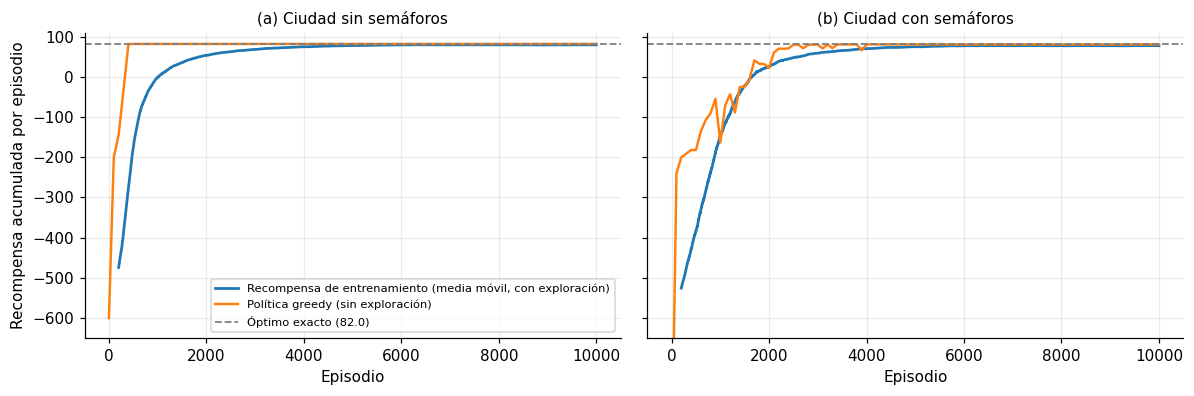

sin semáforos : recompensa media de los primeros 200 episodios =  -474.2 | últimos 500 =  79.8 | óptimo = 82.0
con semáforos : recompensa media de los primeros 200 episodios =  -525.4 | últimos 500 =  77.7 | óptimo = 80.8


In [12]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.7), sharey=True)
graficar_curvas(axs[0], hists_sin, "(a) Ciudad sin semáforos", opt_sin)
graficar_curvas(axs[1], hists, "(b) Ciudad con semáforos", opt_medio, leyenda=False)
axs[1].set_ylabel("")
plt.tight_layout(); plt.savefig("figuras/fig_recompensa.png", bbox_inches="tight"); plt.show()
for nombre, hs, opt in [("sin semáforos", hists_sin, opt_sin), ("con semáforos", hists, opt_medio)]:
    prom = np.mean([np.mean(h["retorno"][:200]) for h in hs]); fin = np.mean([np.mean(h["retorno"][-500:]) for h in hs])
    print(f"{nombre:14s}: recompensa media de los primeros 200 episodios = {prom:7.1f} | últimos 500 = {fin:5.1f} | óptimo = {opt:.1f}")

**Lectura.** Al principio el agente casi nunca llega (recompensa ≈ −500: choca y agota los 200 pasos). Hacia el episodio 1 500 ya llega casi siempre y después afina la ruta. La recompensa de *entrenamiento* queda algo por debajo del óptimo porque sigue explorando (ε mínimo 0.05); la curva naranja, que evalúa la política sin exploración, sí alcanza el óptimo.

### Paso 4.6 · Evaluar la política desde cada fase del ciclo
Se le pide al agente que conduzca *sin explorar* saliendo en cada una de las 6 fases posibles, y se compara con el óptimo exacto.

In [13]:
def tabla_por_fase(env, Q):
    filas = []
    for r, o in zip(evaluar_politica(env, Q), opt_fases):
        filas.append({"Fase inicial": r["fase0"], "Pasos (con esperas)": r["pasos"], "Esperas": r["esperas"],
                      "Multas": r["multas"], "Choques": r["choques"], "Retorno": r["retorno"], "Óptimo": o,
                      "¿Es óptimo?": "sí" if abs(r["retorno"] - o) < 1e-9 else "no"})
    return pd.DataFrame(filas).set_index("Fase inicial")


tabla_fases = tabla_por_fase(env, Qs[0])
display(tabla_fases)
n_opt = [sum(abs(r["retorno"] - o) < 1e-9 for r, o in zip(evaluar_politica(env, Q), opt_fases)) for Q in Qs]
print("Fases (de 6) en que la política alcanza el retorno óptimo, por semilla:", n_opt)

,Pasos (con esperas),Esperas,Multas,Choques,Retorno,Óptimo,¿Es óptimo?
Fase inicial,,,,,,,
0,18,0,0,0,82.00,82.00,sí
1,18,0,0,0,82.00,82.00,sí
2,20,0,0,0,80.00,80.00,sí
3,20,0,0,0,80.00,80.00,sí
4,20,2,0,0,80.00,80.00,sí
5,19,1,0,0,81.00,81.00,sí


Fases (de 6) en que la política alcanza el retorno óptimo, por semilla: [6, 6, 6, 6, 6]


### Paso 4.7 · Ver las 6 rutas aprendidas
Cada mapa corresponde a una fase de salida. Cada semáforo se pinta con el color que tenía **en el momento en que el agente lo cruzó** (ámbar = no lo cruzó en ese recorrido); las etiquetas “espera ×k” marcan dónde el agente se detiene.

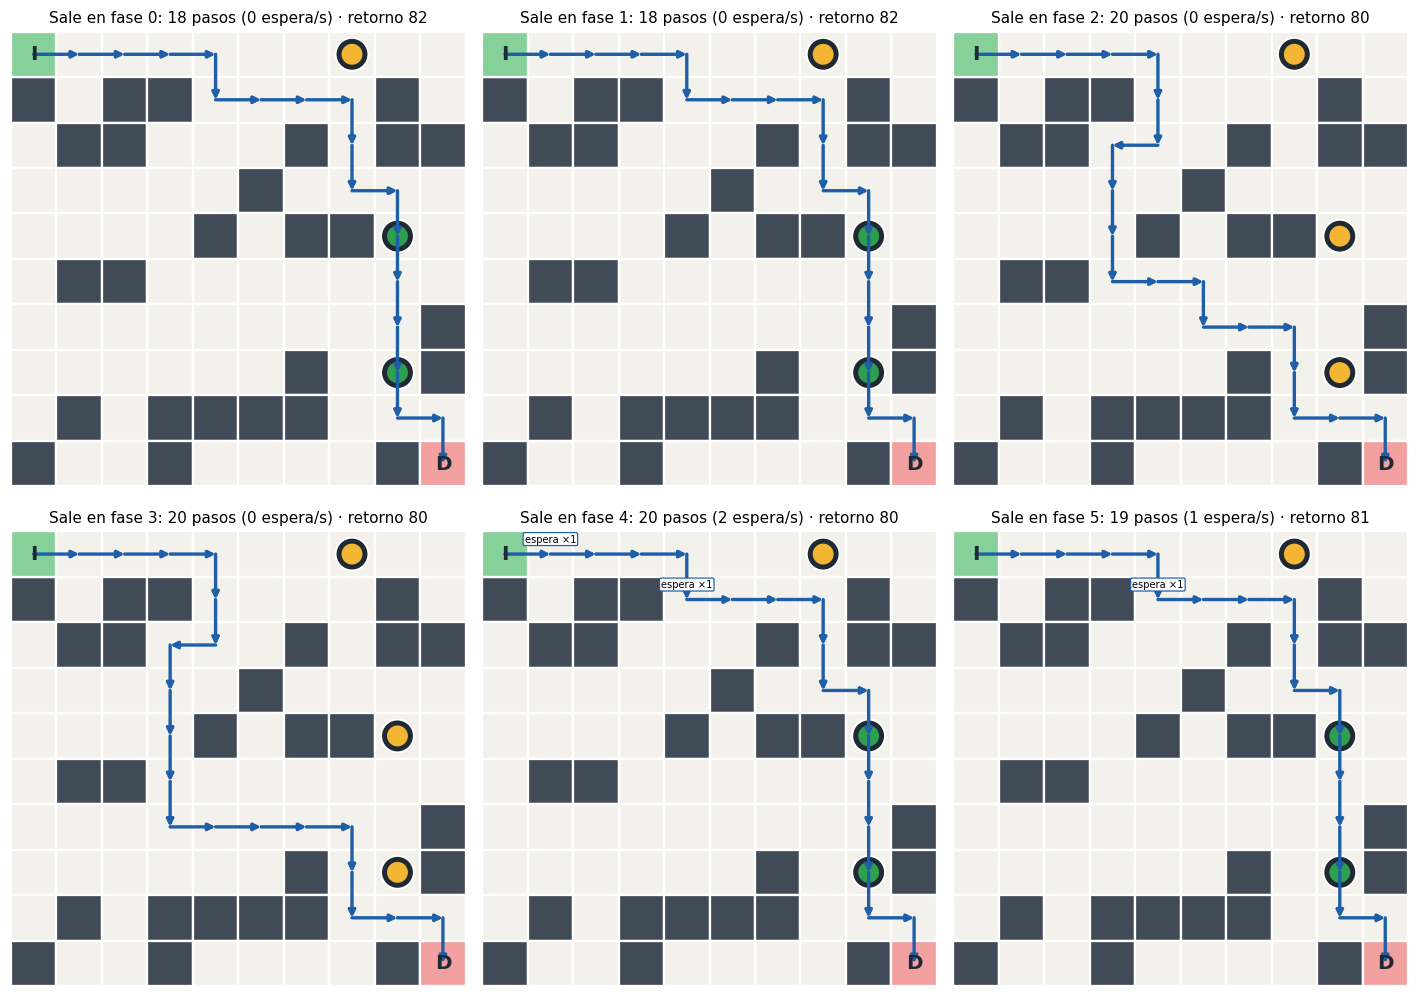

In [14]:
fig, axs = plt.subplots(2, 3, figsize=(13, 9.4))
for ax, r in zip(axs.ravel(), evaluar_politica(env, Qs[0])):
    dibujar_ciudad(env, ax, [dict(ruta=r["ruta"], color="#1F5FA8")],
                   f"Sale en fase {r['fase0']}: {r['pasos']} pasos ({r['esperas']} espera/s) · retorno {r['retorno']:.0f}",
                   colores_al_cruzar(env, r))
plt.tight_layout(); plt.savefig("figuras/fig_rutas_por_fase.png", bbox_inches="tight"); plt.show()

### Paso 4.8 · La decisión central: ¿esperar o tomar la ruta alternativa?
Para responder con precisión, calculamos (con Dijkstra) el **mejor costo posible** en dos familias de rutas, para cada fase de salida:
* **Cruzar semáforos** (pudiendo esperar en ellos el tiempo que convenga), y
* **Evitar todos los semáforos** (ruta alternativa de 20 pasos).

El costo es `pasos + esperas` (más multas si hubiese). La menor de las dos es la decisión racional.

In [15]:
filas = []
for f in range(env.periodo):
    usar, evitar = ruta_optima(env, f, "usar"), ruta_optima(env, f, "evitar")
    c_usar, c_evitar = env.r_meta - usar["retorno"], env.r_meta - evitar["retorno"]
    if c_usar < c_evitar:
        dec = "cruzar semáforos" + (f" (esperando {usar['esperas']})" if usar["esperas"] else " (sin esperar: 'onda verde')")
    elif c_usar > c_evitar:
        dec = "desviarse (evitar semáforos)"
    else:
        dec = "empate: esperar = desviarse"
    filas.append({"Fase inicial": f, "Costo cruzando semáforos": c_usar, "Costo evitándolos": c_evitar, "Decisión racional": dec})
tabla_decision = pd.DataFrame(filas).set_index("Fase inicial")
display(tabla_decision)

,Costo cruzando semáforos,Costo evitándolos,Decisión racional
Fase inicial,,,
0,18.00,20.00,cruzar semáforos (sin esperar: 'onda verde')
1,18.00,20.00,cruzar semáforos (sin esperar: 'onda verde')
2,22.00,20.00,desviarse (evitar semáforos)
3,21.00,20.00,desviarse (evitar semáforos)
4,20.00,20.00,empate: esperar = desviarse
5,19.00,20.00,cruzar semáforos (esperando 1)


**Lectura.** La mejor decisión cambia con la fase de salida:
* **Fases 0 y 1:** los semáforos coinciden en verde al llegar; cruzarlos **sin esperar** cuesta 18 (“onda verde”) y gana la ruta corta.
* **Fase 5:** conviene cruzar **esperando 1 paso** (costo 19 < 20).
* **Fases 2 y 3:** esperar en los semáforos sale más caro (22 y 21) que la ruta alternativa (20), así que conviene **desviarse**.
* **Fase 4:** empate exacto (20 = 20); cualquiera de las dos opciones es óptima (el agente eligió esperar 2 pasos, ver 4.6).

Esto responde el punto 4 del enunciado: **el agente decide entre esperar y desviarse comparando los costos, y la decisión depende de en qué momento del ciclo empieza.**

### Paso 4.9 · Mapa de decisiones: ¿dónde importa la fase?
Recorremos el mapa con la política del agente saliendo desde las 6 fases y anotamos qué acción toma en cada celda por la que pasa. Si toma **siempre la misma**, se dibuja una flecha azul (○ = esperar). Si la acción **depende de la fase del ciclo**, la celda se pinta de naranja y se listan las acciones posibles. Así se ve dónde está “la inteligencia” de la política.

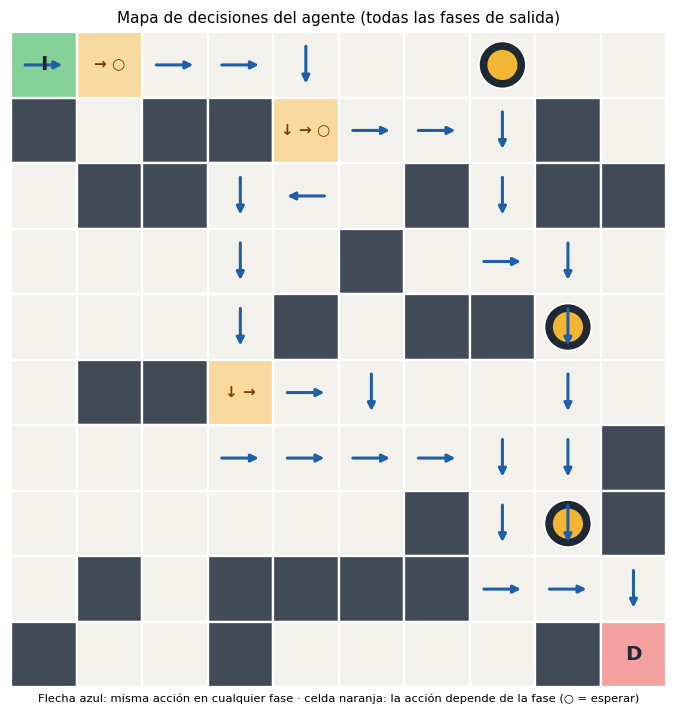

Celdas por las que pasa el agente: 32 | con decisión que depende de la fase: 3


In [16]:
fig, ax = plt.subplots(figsize=(6.6, 6.6))
dibujar_decisiones(env, Qs[0], ax, "Mapa de decisiones del agente (todas las fases de salida)")
plt.tight_layout(); plt.savefig("figuras/fig_mapa_decisiones.png", bbox_inches="tight"); plt.show()
n_dep = sum(len(set(v.values())) > 1 for v in acciones_por_celda(env, Qs[0]).values())
print(f"Celdas por las que pasa el agente: {len(acciones_por_celda(env, Qs[0]))} | con decisión que depende de la fase: {n_dep}")

**Lectura.** De las 32 celdas por las que pasa el agente, solo **3** tienen una decisión que depende de la fase: la segunda celda del recorrido (avanzar o esperar ○), la celda (1,4) (bajar hacia el desvío, seguir por la avenida o esperar) y la (5,3). En todas las demás la acción es siempre la misma.

Hay además un detalle interesante: **el agente nunca espera frente a un semáforo.** Cuando le conviene esperar, lo hace *antes* (en las celdas (0,1) y (1,4)) para *sincronizar su llegada* con el verde. Cuesta lo mismo (−1 por instante), pero evita quedar detenido en la intersección. Es la misma idea de una “onda verde” en una avenida real.

### Paso 4.10 · Figura resumen para el informe
Panel (a): la ciudad con todas las rutas de referencia. Paneles (b) y (c): dos recorridos del agente entrenado que ilustran las dos decisiones típicas. Los semáforos aparecen con el color que tenían cuando el agente los cruzó (ámbar = no los cruzó).

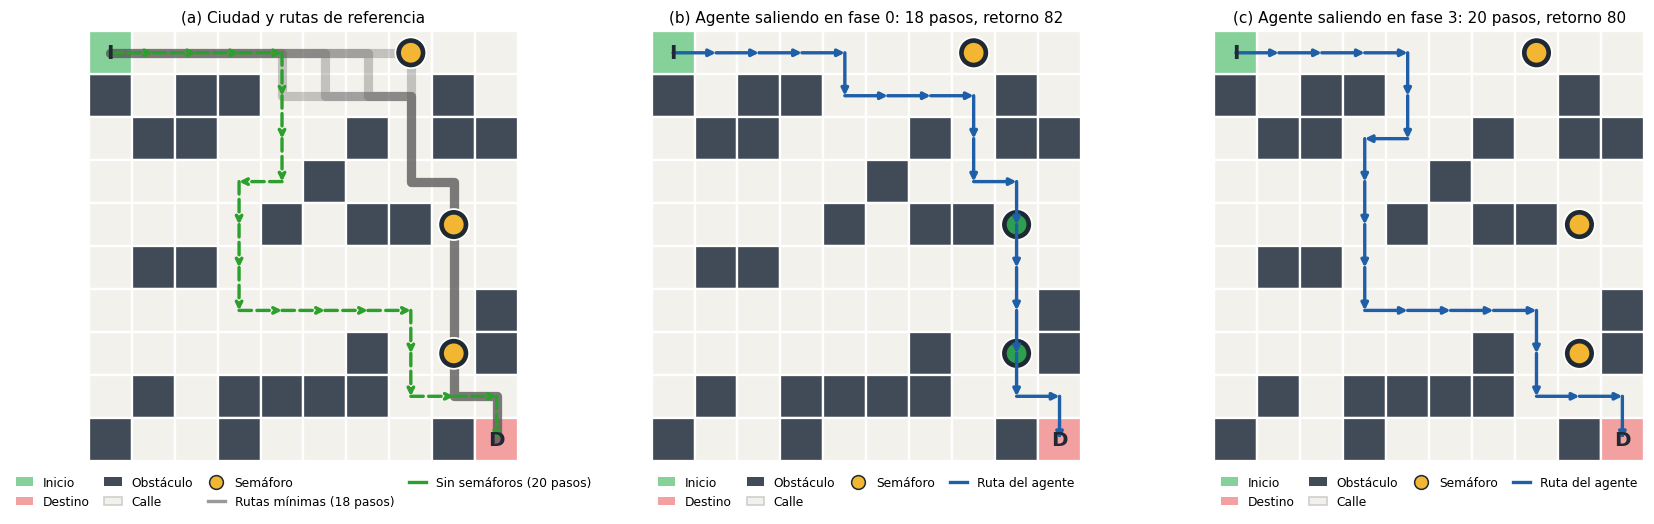

In [17]:
r0, r3 = rollout(env, Qs[0], 0), rollout(env, Qs[0], 3)
fig, axs = plt.subplots(1, 3, figsize=(15.5, 5.9))
dibujar_ciudad(env, axs[0], [dict(ruta=r, color="#555555", fondo=True) for r in rutas_cortas]
               + [dict(ruta=rutas_libres[0], color="#2CA02C", estilo="--")], "(a) Ciudad y rutas de referencia")
leyenda_mapa(axs[0], extra=[("Rutas mínimas (18 pasos)", "#999999"), ("Sin semáforos (20 pasos)", "#2CA02C")])
for ax, r, letra in [(axs[1], r0, "(b)"), (axs[2], r3, "(c)")]:
    dibujar_ciudad(env, ax, [dict(ruta=r["ruta"], color="#1F5FA8")],
                   f"{letra} Agente saliendo en fase {r['fase0']}: {r['pasos']} pasos, retorno {r['retorno']:.0f}",
                   colores_al_cruzar(env, r))
    leyenda_mapa(ax, extra=[("Ruta del agente", "#1F5FA8")])
plt.tight_layout(); plt.savefig("figuras/fig_informe_rutas.png", bbox_inches="tight"); plt.show()

### Paso 4.11 · Animación: el agente conduciendo
Dos “conductores” idénticos (la misma tabla Q) que salen en fases distintas. Los semáforos cambian de color con el tiempo. Un conductor aprovecha la onda verde; el otro toma otra decisión.

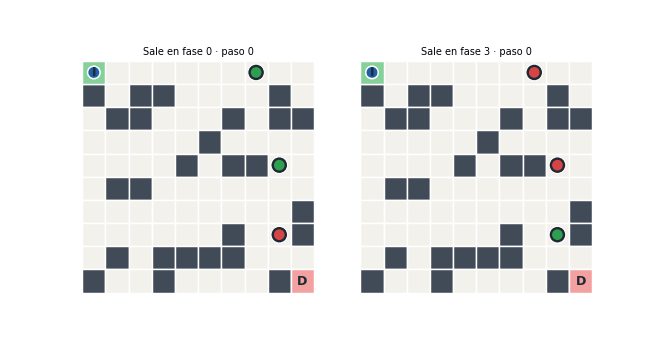

In [18]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image


def animar(env, Q, fases, archivo, fps=2):
    recorridos = [rollout(env, Q, f) for f in fases]
    T = max(r["pasos"] for r in recorridos) + 4
    fig, axs = plt.subplots(1, len(fases), figsize=(4.7 * len(fases), 5.0))
    def cuadro(k):
        for ax, r, f in zip(axs, recorridos, fases):
            kk = min(k, r["pasos"]); ax.clear()
            col = {c: COLORES["rojo" if env.es_rojo(c, f + kk) else "verde"] for c in env.semaforos_mapa}
            estado = f"¡llegó en {r['pasos']} pasos!" if k >= r["pasos"] else f"paso {kk}"
            dibujar_ciudad(env, ax, [dict(ruta=r["ruta"][:kk + 1], color="#1F5FA8")],
                           f"Sale en fase {f} · {estado}", col)
            x, y = _centro(r["ruta"][kk])
            ax.add_patch(Circle((x, y), 0.27, fc="#1F5FA8", ec="white", lw=1.6, zorder=9))
    anim = FuncAnimation(fig, cuadro, frames=T)
    anim.save(archivo, writer=PillowWriter(fps=fps), dpi=70)
    plt.close(fig)


animar(env, Qs[0], [0, 3], "figuras/animacion_agente.gif")
Image(filename="figuras/animacion_agente.gif")

---
## 5. Experimentar: ¿qué cambia cuando se modifican los parámetros o la recompensa?

**Método (paso a paso).**
1. Partimos de la configuración *base* (la de las secciones anteriores).
2. Cambiamos **un solo factor a la vez**, de modo que cualquier diferencia pueda atribuirse a ese factor.
3. Cada configuración se entrena con **5 semillas** (10 000 episodios) y se evalúa con la política *greedy* saliendo desde las 6 fases.
4. Medimos: **retorno** (recompensa acumulada del recorrido), **brecha** frente al óptimo exacto, **pasos**, **esperas**, **cruces en rojo**, **éxito** (% de recorridos que llegan) y **episodios para converger** (primer episodio a partir del cual la política greedy queda en el óptimo).

Las 5 familias de experimentos: **A** tasa de aprendizaje α · **B** factor de descuento γ · **C** exploración e inicialización · **D** función de recompensa · **E** semáforos (duración del verde y visibilidad del ciclo).

In [19]:
def converge(eval_ep, eval_ret, optimo, tol=0.01):
    """Primer episodio desde el cual la política greedy se mantiene en el óptimo."""
    ok = [r >= optimo - tol for r in eval_ret]
    for i in range(len(ok)):
        if all(ok[i:]): return eval_ep[i]
    return None


CACHE, RES = {}, {}
CACHE[((), ())] = (env, Qs, hists)                    # la configuración base ya está entrenada


def ejecutar_config(nombre, env_kw=None, tr_kw=None):
    env_kw, tr_kw = env_kw or {}, tr_kw or {}
    clave = (tuple(sorted(env_kw.items())), tuple(sorted(tr_kw.items())))
    if clave not in CACHE:
        e, t0 = EntornoCiudad(**env_kw), time.time()
        res = [entrenar(e, semilla=s, **{**CONFIG_BASE, **tr_kw}) for s in SEMILLAS]
        CACHE[clave] = (e, [r[0] for r in res], [r[1] for r in res])
        print(f"   {nombre:34s} {time.time() - t0:4.0f} s")
    e, Qs_, hs_ = CACHE[clave]
    opt = float(np.mean(retornos_optimos(EntornoCiudad(**{**env_kw, "ve_semaforos": True}))))
    evals = [evaluar_politica(e, Q) for Q in Qs_]
    ret_sem = [np.mean([x["retorno"] for x in ev]) for ev in evals]
    todos = [x for ev in evals for x in ev]
    conv = [converge(h["eval_ep"], h["eval_ret"], opt) for h in hs_]
    ok = [c for c in conv if c is not None]
    res = dict(nombre=nombre, hists=hs_, opt=opt, ret=float(np.mean(ret_sem)), multas=np.mean([x["multas"] for x in todos]),
               esperas=np.mean([x["esperas"] for x in todos]),
               fila={"Configuración": nombre, "Retorno": np.mean(ret_sem), "Desv.": np.std(ret_sem), "Óptimo": opt,
                     "Brecha": opt - np.mean(ret_sem), "Pasos": np.mean([x["pasos"] for x in todos]),
                     "Esperas": np.mean([x["esperas"] for x in todos]), "Cruces en rojo": np.mean([x["multas"] for x in todos]),
                     "Éxito": np.mean([x["exito"] for x in todos]),
                     "Recomp. entren.": np.mean([np.mean(h["retorno"][-1000:]) for h in hs_]),
                     "Convergencia (ep.)": f"{np.mean(ok):,.0f} ({len(ok)}/{len(conv)})" if ok else f"no converge (0/{len(conv)})"})
    RES[nombre] = res
    return res


BASE = "Base"
EXPERIMENTOS = {
    "A · Tasa de aprendizaje α": [("α = 0.01", {}, dict(alpha=0.01)), ("α = 0.05", {}, dict(alpha=0.05)),
                                  (BASE, {}, {}), ("α = 0.5", {}, dict(alpha=0.5))],
    "B · Factor de descuento γ": [("γ = 0.5", {}, dict(gamma=0.5)), ("γ = 0.9", {}, dict(gamma=0.9)),
                                  (BASE, {}, {}), ("γ = 0.999", {}, dict(gamma=0.999))],
    "C · Exploración e inicialización de Q": [
        (BASE, {}, {}),
        ("Q0=0, ε 1→0.05", {}, dict(q_ini=0.0)),
        ("Q0=0, ε=0 (solo explotar)", {}, dict(q_ini=0.0, eps_ini=0.0, eps_fin=0.0)),
        ("Q0=0, ε=0.05 fijo", {}, dict(q_ini=0.0, eps_ini=0.05, eps_fin=0.05)),
        ("Q0=0, ε=0.3 fijo", {}, dict(q_ini=0.0, eps_ini=0.3, eps_fin=0.3)),
        ("Q0=100, ε=0 (solo explotar)", {}, dict(eps_ini=0.0, eps_fin=0.0)),
        ("Q0=100, ε=0.5 fijo", {}, dict(eps_ini=0.5, eps_fin=0.5))],
    "D · Función de recompensa": [("multa 0", dict(r_rojo=0.0), {}), ("multa −2", dict(r_rojo=-2.0), {}),
                                  ("multa −5", dict(r_rojo=-5.0), {}), (BASE, {}, {}),
                                  ("costo por paso −0.1", dict(r_paso=-0.1), {}), ("costo por paso 0", dict(r_paso=0.0), {})],
    "E · Semáforos": [("verde 1 de 6", dict(verde=1), {}), (BASE, {}, {}), ("verde 5 de 6", dict(verde=5), {}),
                      ("agente ciego a la fase", dict(ve_semaforos=False), {})],
}
print("Entrenando configuraciones (las ya entrenadas se reutilizan)...")
TABLAS = {}
for familia, configs in EXPERIMENTOS.items():
    filas = [ejecutar_config(n, e, t)["fila"] for n, e, t in configs]
    TABLAS[familia] = pd.DataFrame(filas).set_index("Configuración")
print("Listo.")

Entrenando configuraciones (las ya entrenadas se reutilizan)...
   α = 0.01                             85 s
   α = 0.05                             32 s
   α = 0.5                              22 s
   γ = 0.5                              26 s
   γ = 0.9                              25 s
   γ = 0.999                            24 s
   Q0=0, ε 1→0.05                       22 s
   Q0=0, ε=0 (solo explotar)            19 s
   Q0=0, ε=0.05 fijo                    19 s
   Q0=0, ε=0.3 fijo                     31 s
   Q0=100, ε=0 (solo explotar)          24 s
   Q0=100, ε=0.5 fijo                   33 s
   multa 0                              22 s
   multa −2                             23 s
   multa −5                             25 s
   costo por paso −0.1                  24 s
   costo por paso 0                     24 s
   verde 1 de 6                         25 s
   verde 5 de 6                         22 s
   agente ciego a la fase               21 s
Listo.


### Resultados por familia
**Cómo leer las tablas.** *Brecha* = óptimo − retorno (0 = política óptima). *Pasos* incluye las esperas. *Recomp. entren.* es la recompensa media de los últimos 1 000 episodios de entrenamiento (con exploración). *Convergencia* indica en qué episodio la política greedy queda en el óptimo y en cuántas de las 5 semillas ocurrió.

In [20]:
for familia, tabla in TABLAS.items():
    print(f"\n=== {familia} ===")
    display(tabla)


=== A · Tasa de aprendizaje α ===


,Retorno,Desv.,Óptimo,Brecha,Pasos,Esperas,Cruces en rojo,Éxito,Recomp. entren.,Convergencia (ep.)
Configuración,,,,,,,,,,
α = 0.01,-163.23,192.35,80.83,244.07,132.40,28.30,0.00,0.40,0.76,no converge (0/5)
α = 0.05,80.43,0.43,80.83,0.40,19.40,0.57,0.00,1.00,76.58,"9,999 (2/5)"
Base,80.83,0.00,80.83,0.00,19.17,0.37,0.00,1.00,77.64,"4,520 (5/5)"
α = 0.5,80.83,0.00,80.83,0.00,19.17,0.17,0.00,1.00,77.59,640 (5/5)



=== B · Factor de descuento γ ===


,Retorno,Desv.,Óptimo,Brecha,Pasos,Esperas,Cruces en rojo,Éxito,Recomp. entren.,Convergencia (ep.)
Configuración,,,,,,,,,,
γ = 0.5,80.83,0.00,80.83,0.00,19.17,0.30,0.00,1.00,77.76,"5,660 (5/5)"
γ = 0.9,80.83,0.00,80.83,0.00,19.17,0.43,0.00,1.00,77.50,"4,100 (5/5)"
Base,80.83,0.00,80.83,0.00,19.17,0.37,0.00,1.00,77.64,"4,520 (5/5)"
γ = 0.999,80.83,0.00,80.83,0.00,19.17,0.30,0.00,1.00,77.68,"5,140 (5/5)"



=== C · Exploración e inicialización de Q ===


,Retorno,Desv.,Óptimo,Brecha,Pasos,Esperas,Cruces en rojo,Éxito,Recomp. entren.,Convergencia (ep.)
Configuración,,,,,,,,,,
Base,80.83,0.00,80.83,0.00,19.17,0.37,0.00,1.00,77.64,"4,520 (5/5)"
"Q0=0, ε 1→0.05",80.33,0.00,80.83,0.50,19.67,0.67,0.00,1.00,76.88,no converge (0/5)
"Q0=0, ε=0 (solo explotar)",77.23,3.19,80.83,3.60,21.10,1.50,0.00,1.00,77.28,no converge (0/5)
"Q0=0, ε=0.05 fijo",78.90,0.80,80.83,1.93,21.10,1.77,0.00,1.00,73.10,no converge (0/5)
"Q0=0, ε=0.3 fijo",79.63,0.68,80.83,1.20,20.37,1.30,0.00,1.00,35.75,no converge (0/5)
"Q0=100, ε=0 (solo explotar)",80.83,0.00,80.83,0.00,19.17,0.23,0.00,1.00,80.77,"8,720 (5/5)"
"Q0=100, ε=0.5 fijo",80.83,0.00,80.83,0.00,19.17,0.17,0.00,1.00,16.10,"2,800 (5/5)"



=== D · Función de recompensa ===


,Retorno,Desv.,Óptimo,Brecha,Pasos,Esperas,Cruces en rojo,Éxito,Recomp. entren.,Convergencia (ep.)
Configuración,,,,,,,,,,
multa 0,82.00,0.00,82.00,0.00,18.00,0.00,1.00,1.00,79.60,"2,660 (5/5)"
multa −2,80.83,0.00,80.83,0.00,18.83,0.30,0.17,1.00,78.00,"4,860 (5/5)"
multa −5,80.83,0.00,80.83,0.00,19.17,0.30,0.00,1.00,77.84,"4,000 (5/5)"
Base,80.83,0.00,80.83,0.00,19.17,0.37,0.00,1.00,77.64,"4,520 (5/5)"
costo por paso −0.1,98.08,0.00,98.08,0.00,19.17,0.30,0.00,1.00,96.30,"3,840 (5/5)"
costo por paso 0,100.00,0.00,100.00,0.00,19.17,0.23,0.00,1.00,98.43,"2,120 (5/5)"



=== E · Semáforos ===


,Retorno,Desv.,Óptimo,Brecha,Pasos,Esperas,Cruces en rojo,Éxito,Recomp. entren.,Convergencia (ep.)
Configuración,,,,,,,,,,
verde 1 de 6,80.17,0.00,80.17,0.00,19.83,0.43,0.00,1.00,76.89,"3,460 (5/5)"
Base,80.83,0.00,80.83,0.00,19.17,0.37,0.00,1.00,77.64,"4,520 (5/5)"
verde 5 de 6,81.50,0.00,81.50,0.00,18.50,0.30,0.00,1.00,78.83,"6,300 (5/5)"
agente ciego a la fase,80.00,0.00,80.83,0.83,20.00,0.00,0.00,1.00,77.58,no converge (0/5)


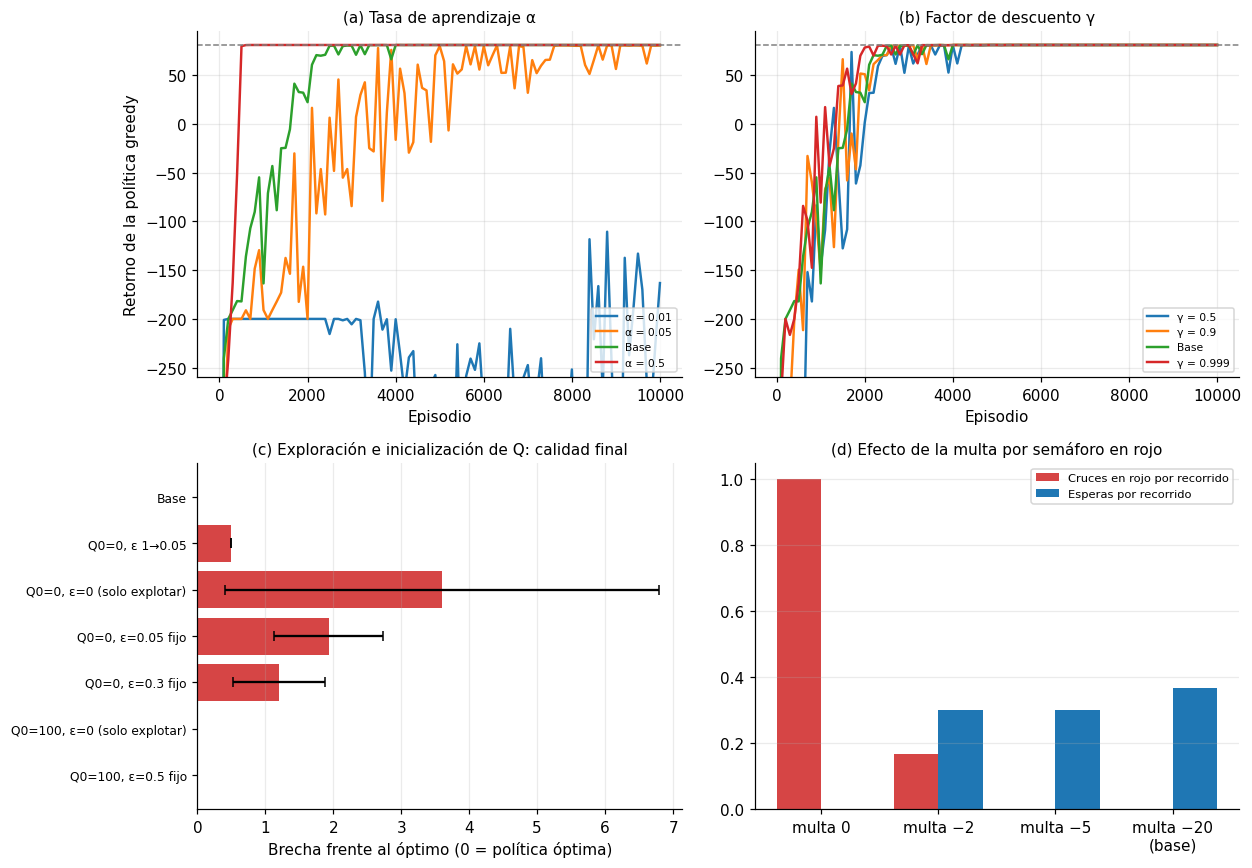

In [21]:
def graficar_familia(ax, nombres, titulo, ylim=(-260, 95), leyenda_fs=7):
    for n, col in zip(nombres, plt.cm.tab10.colors):
        r = RES[n]
        ax.plot(r["hists"][0]["eval_ep"], np.array([h["eval_ret"] for h in r["hists"]]).mean(0), color=col, lw=1.6, label=n)
    ax.axhline(RES[nombres[0]]["opt"], color="gray", ls="--", lw=1)
    ax.set_ylim(*ylim); ax.set_xlabel("Episodio"); ax.set_title(titulo, fontsize=10); ax.grid(alpha=0.25)
    ax.legend(fontsize=leyenda_fs, loc="lower right")


fig, axs = plt.subplots(2, 2, figsize=(11.5, 8))
graficar_familia(axs[0, 0], [n for n, _, _ in EXPERIMENTOS["A · Tasa de aprendizaje α"]], "(a) Tasa de aprendizaje α")
graficar_familia(axs[0, 1], [n for n, _, _ in EXPERIMENTOS["B · Factor de descuento γ"]], "(b) Factor de descuento γ")
axs[0, 0].set_ylabel("Retorno de la política greedy")
nombres_c = [n for n, _, _ in EXPERIMENTOS["C · Exploración e inicialización de Q"]]
brechas = [TABLAS["C · Exploración e inicialización de Q"].loc[n, "Brecha"] for n in nombres_c]
desv = [TABLAS["C · Exploración e inicialización de Q"].loc[n, "Desv."] for n in nombres_c]
ypos = np.arange(len(nombres_c))[::-1]
axs[1, 0].barh(ypos, brechas, xerr=desv, color=["#2E9E4F" if b < 0.01 else "#D64545" for b in brechas], capsize=3)
axs[1, 0].set_yticks(ypos); axs[1, 0].set_yticklabels(nombres_c, fontsize=8)
axs[1, 0].set_xlabel("Brecha frente al óptimo (0 = política óptima)")
axs[1, 0].set_title("(c) Exploración e inicialización de Q: calidad final", fontsize=10); axs[1, 0].grid(alpha=0.25, axis="x")
nombres_d = ["multa 0", "multa −2", "multa −5", BASE]
x, w = np.arange(len(nombres_d)), 0.38
axs[1, 1].bar(x - w / 2, [RES[n]["multas"] for n in nombres_d], w, color=COLORES["rojo"], label="Cruces en rojo por recorrido")
axs[1, 1].bar(x + w / 2, [RES[n]["esperas"] for n in nombres_d], w, color="#1F77B4", label="Esperas por recorrido")
axs[1, 1].set_xticks(x); axs[1, 1].set_xticklabels(["multa 0", "multa −2", "multa −5", "multa −20\n(base)"])
axs[1, 1].set_title("(d) Efecto de la multa por semáforo en rojo", fontsize=10); axs[1, 1].legend(fontsize=7.5); axs[1, 1].grid(alpha=0.25, axis="y")
plt.tight_layout(); plt.savefig("figuras/fig_experimentos.png", bbox_inches="tight"); plt.show()

### Lectura de los experimentos

**A · α (tasa de aprendizaje).** Con α = 0.01 el agente no logra aprender en 10 000 episodios (solo el 40 % de los recorridos llega). α = 0.05 llega al óptimo apenas al final y solo en 2 de 5 semillas. α = 0.1 converge hacia el episodio ~4 500 y α = 0.5 hacia el ~640. En este entorno **determinista** un α alto es seguro porque no hay ruido que promediar; en un entorno con ruido, un α grande haría oscilar la tabla Q.

**B · γ (descuento).** Entre 0.5 y 0.999 la **política final es la misma**. γ cambia la magnitud de los valores Q, no el orden entre acciones, porque hay una recompensa terminal y todas las rutas comparadas tienen longitudes muy parecidas (18–20 pasos). Solo hay diferencias pequeñas en la velocidad de convergencia. (En mapas mucho más grandes, un γ bajo haría que la recompensa de la meta “desapareciera” antes de llegar al inicio.)

**C · Exploración.** Con la inicialización clásica (Q0 = 0) el agente **se queda en una política subóptima** (retorno entre 77.2 y 80.3 frente a 80.83), sea cual sea el ε. La razón: cerca del destino los valores Q son positivos, así que las acciones no probadas (valor 0) *parecen peores* que las conocidas y el agente casi nunca prueba la ruta alternativa de 20 pasos. Con la inicialización optimista (Q0 = 100) ocurre lo contrario: todo lo desconocido parece atractivo y se explora de forma sistemática, por lo que **las 5 semillas llegan al óptimo**. Incluso con ε = 0 funciona, aunque más lento (~8 700 episodios). Un ε fijo muy alto (0.5) también llega al óptimo, pero la recompensa de entrenamiento es muy baja (~16) porque el agente sigue actuando al azar la mitad del tiempo.

**D · Función de recompensa.** Es el factor que **más cambia el comportamiento**:
* **Sin multa** el agente cruza los semáforos en rojo en promedio 1 vez por recorrido y obtiene *más* recompensa (82 > 80.83): la recompensa “premia” un mal comportamiento (*reward hacking*).
* Con una multa de −2 cruza en rojo en algunas fases (0.17 cruces por recorrido) porque le sale casi al mismo costo que esperar.
* Con −5 o más **obedece siempre**.
* Cambiar el costo por paso (−1, −0.1 o 0) no cambia el comportamiento, solo la escala del retorno.

**E · Semáforos.** Cuanto más tiempo en verde, menor el costo del mejor recorrido (óptimo 80.17 con 1/6 de verde, 80.83 con 3/6 y 81.50 con 5/6). Y un **agente ciego a la fase** del ciclo aprende a evitar todos los semáforos (20 pasos, sin esperas ni multas) y termina con retorno 80.0: pierde en promedio 0.83 puntos frente al agente que sí ve el ciclo. Ese es el “valor” de conocer el estado de los semáforos.

---
## 6. ¿La ruta aprendida es realmente la más corta?

**Respuesta corta:** la ruta del agente es la **mejor** (máximo retorno), pero **no siempre es la más corta en celdas**. Lo mostramos comparando cinco “conductores” en el mismo entorno, saliendo desde cada fase del ciclo.

### Paso 6.1 · Definir a los cinco conductores
| Conductor | Qué hace |
|---|---|
| **Apurado** | Toma la ruta más corta (18) e ignora los rojos (paga multa) |
| **Paciente** | Toma la mejor de las rutas cortas y espera el verde |
| **Precavido** | Evita todos los semáforos (ruta de 20 pasos) |
| **Agente Q-Learning** | Sigue su política aprendida |
| **Óptimo (Dijkstra)** | Planificador con información perfecta: cota máxima de retorno |

In [22]:
def evaluar_ruta_fija(env, ruta, fase0, esperar_en_rojo=True):
    """Retorno de seguir una ruta fija; en un semáforo rojo espera (o cruza y paga la multa)."""
    t, ret = fase0, 0.0
    for celda in ruta[1:]:
        if celda in env.semaforos and env.es_rojo(celda, t):
            if esperar_en_rojo:
                while env.es_rojo(celda, t):
                    t += 1; ret += env.r_paso
            else:
                ret += env.r_rojo
        ret += env.r_paso; t += 1
    return ret + env.r_meta


conductores = {
    "Apurado (ruta corta, ignora rojos)": lambda f: evaluar_ruta_fija(env, rutas_cortas[0], f, esperar_en_rojo=False),
    "Paciente (ruta corta, espera verde)": lambda f: max(evaluar_ruta_fija(env, r, f) for r in rutas_cortas),
    "Precavido (evita semáforos)": lambda f: evaluar_ruta_fija(env, rutas_libres[0], f),
    "Agente Q-Learning": lambda f: rollout(env, Qs[0], f)["retorno"],
    "Óptimo (Dijkstra)": lambda f: opt_fases[f],
}
comparacion = pd.DataFrame({n: [fn(f) for f in range(env.periodo)] for n, fn in conductores.items()})
comparacion.index.name = "Fase inicial"
comparacion.loc["Media"] = comparacion.mean()
display(comparacion)

,"Apurado (ruta corta, ignora rojos)","Paciente (ruta corta, espera verde)",Precavido (evita semáforos),Agente Q-Learning,Óptimo (Dijkstra)
Fase inicial,,,,,
0,82.00,82.00,80.00,82.00,82.00
1,82.00,82.00,80.00,82.00,82.00
2,62.00,78.00,80.00,80.00,80.00
3,42.00,79.00,80.00,80.00,80.00
4,42.00,80.00,80.00,80.00,80.00
5,62.00,81.00,80.00,81.00,81.00
Media,62.00,80.33,80.00,80.83,80.83


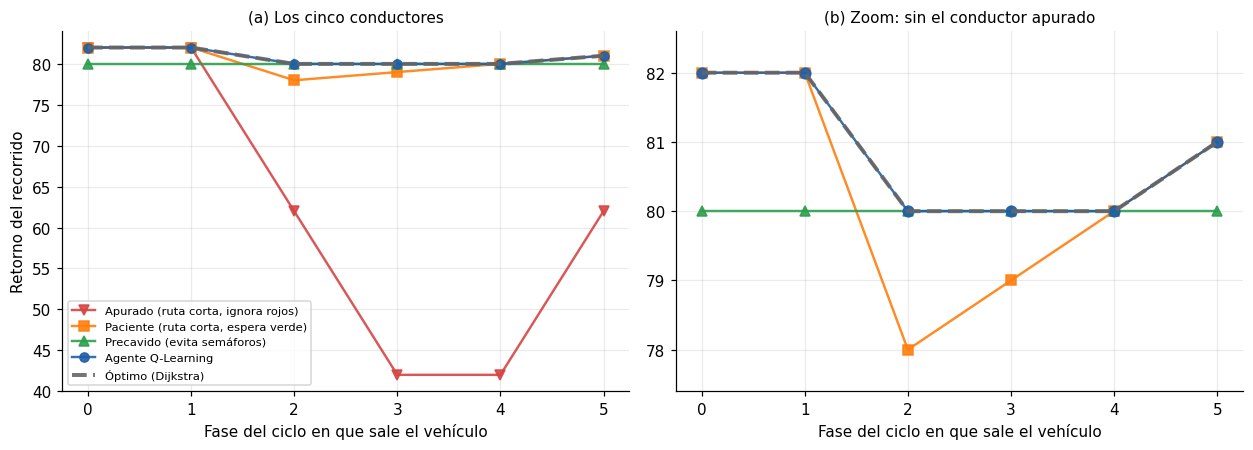

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.2))
estilos = [("#D64545", "v", "-"), ("#FF7F0E", "s", "-"), ("#2E9E4F", "^", "-"), ("#1F5FA8", "o", "-"), ("#666666", None, "--")]
for k, ax in enumerate(axs):
    for (n, (col, mk, ls)) in zip(conductores, estilos):
        if k == 1 and n.startswith("Apurado"): continue           # el panel derecho hace zoom sin el conductor apurado
        ax.plot(range(env.periodo), comparacion[n].iloc[:-1], color=col, marker=mk, ls=ls, lw=2.6 if mk is None else 1.6,
                ms=7 if k else 6, label=n, alpha=0.9)
    ax.set_xlabel("Fase del ciclo en que sale el vehículo"); ax.grid(alpha=0.25)
axs[0].set_ylabel("Retorno del recorrido"); axs[0].set_title("(a) Los cinco conductores", fontsize=10)
axs[0].legend(fontsize=7.5, loc="lower left")
axs[1].set_ylim(77.4, 82.6); axs[1].set_title("(b) Zoom: sin el conductor apurado", fontsize=10)
plt.tight_layout(); plt.savefig("figuras/fig_comparacion_conductores.png", bbox_inches="tight"); plt.show()

### Paso 6.2 · Comparar la ruta del agente con la ruta más corta
Para cada fase: longitud en pasos, esperas y retorno del agente frente a la ruta más corta (18 pasos, retorno 82 si no hubiera semáforos).

In [24]:
filas = []
for r, o in zip(evaluar_politica(env, Qs[0]), opt_fases):
    filas.append({"Fase inicial": r["fase0"], "Ruta más corta (BFS)": L_min, "Pasos del agente": r["pasos"],
                  "…de los cuales esperas": r["esperas"], "Semáforos que cruza": sum(c in env.semaforos for c in r["ruta"]),
                  "Pasos de más vs. la mínima": r["pasos"] - L_min,
                  "Retorno agente": r["retorno"], "Retorno óptimo": o})
tabla_corta = pd.DataFrame(filas).set_index("Fase inicial")
display(tabla_corta)

,Ruta más corta (BFS),Pasos del agente,…de los cuales esperas,Semáforos que cruza,Pasos de más vs. la mínima,Retorno agente,Retorno óptimo
Fase inicial,,,,,,,
0,18,18,0,2,0,82.00,82.00
1,18,18,0,2,0,82.00,82.00
2,18,20,0,0,2,80.00,80.00
3,18,20,0,0,2,80.00,80.00
4,18,20,2,2,2,80.00,80.00
5,18,19,1,2,1,81.00,81.00


### Paso 6.3 · Evidencia de la “onda verde”
Para las rutas del agente saliendo en las fases 0, 3 y 5 listamos cada semáforo que cruza, en qué instante y de qué color estaba. Así se ve *por qué* el agente puede pasar sin esperar cuando sale en el momento correcto.

In [25]:
def cruces(env, r):
    filas, t = [], r["fase0"]
    for k, (a, b) in enumerate(zip(r["ruta"][:-1], r["ruta"][1:])):
        if a != b and b in env.semaforos:
            filas.append({"Paso": k + 1, "Semáforo": b, "Instante (t mod 6)": (r["fase0"] + k) % env.periodo,
                          "Color al entrar": "rojo" if env.es_rojo(b, r["fase0"] + k) else "verde"})
    return pd.DataFrame(filas)


for f in [0, 3, 5]:
    r = rollout(env, Qs[0], f); c = cruces(env, r)
    print(f"\nSalida en fase {f}: {r['pasos']} pasos, {r['esperas']} esperas.")
    if len(c): display(c)
    else: print("  (esta ruta no cruza ningún semáforo)")


Salida en fase 0: 18 pasos, 0 esperas.


,Paso,Semáforo,Instante (t mod 6),Color al entrar
0,12,"(4, 8)",5,verde
1,15,"(7, 8)",2,verde



Salida en fase 3: 20 pasos, 0 esperas.
  (esta ruta no cruza ningún semáforo)

Salida en fase 5: 19 pasos, 1 esperas.


,Paso,Semáforo,Instante (t mod 6),Color al entrar
0,13,"(4, 8)",5,verde
1,16,"(7, 8)",2,verde


### Paso 6.4 · ¿Qué hace que una ruta sea más conveniente que otra?
Comparando las tablas anteriores, los factores que deciden son:

1. **Número de pasos.** Cada paso cuesta −1: 2 pasos de más restan 2 puntos.
2. **Tiempo perdido esperando.** Esperar también cuesta −1 por instante. Cuánto hay que esperar depende de la **fase del ciclo** con que se llega a cada semáforo (entre 0 y 3 instantes por semáforo).
3. **Sincronización entre semáforos (onda verde).** Si el vehículo sale en el momento justo, encuentra todos los semáforos en verde y la ruta corta no cuesta nada extra (fases 0 y 1).
4. **Penalizaciones.** Con una multa alta cruzar en rojo nunca conviene; con una multa baja o nula, la “mejor” ruta según la recompensa pasa a ser la que ignora los semáforos (sección 5D).
5. **Información disponible.** Sin ver la fase del ciclo, la ruta que evita los semáforos es la más segura, aunque en promedio cueste algo más.
6. **Empates.** Cuando esperar y desviarse cuestan lo mismo (fase 4), existen varias políticas óptimas: el agente puede elegir cualquiera y ninguna es “más correcta”.
7. **Exploración.** Una ruta puede ser mejor y aun así no ser descubierta (sección 5C): que el agente la encuentre depende de cómo explora.

**Conclusión de la sección:** *la ruta más corta en celdas no es necesariamente la mejor ruta*. La mejor es la que maximiza la recompensa acumulada, y eso incluye el tiempo de espera y las penalizaciones. El agente Q-Learning alcanza en las 6 fases el mismo retorno que el planificador óptimo con información perfecta.

In [26]:
# Guardar resultados numéricos (los usa el informe)
import json
resultados = dict(
    L_min=L_min, L_libre=L_libre, n_rutas_minimas=len(rutas_cortas), opt_fases=opt_fases, opt_medio=opt_medio,
    por_fase=tabla_fases.reset_index().to_dict("records"),
    decision=tabla_decision.reset_index().to_dict("records"),
    comparacion=comparacion.reset_index().to_dict("records"),
    experimentos={fam: t.reset_index().to_dict("records") for fam, t in TABLAS.items()},
    fases_optimas_por_semilla=n_opt,
)
with open("figuras/resultados.json", "w", encoding="utf-8") as fh:
    json.dump(resultados, fh, ensure_ascii=False, indent=1, default=float)
print("Resultados guardados en figuras/resultados.json")

Resultados guardados en figuras/resultados.json


---
## 7. Conclusiones

1. **Q-Learning aprende rutas óptimas.** Sin semáforos el agente encuentra una de las 4 rutas mínimas (18 pasos, retorno 82). Con semáforos iguala el retorno del planificador óptimo (Dijkstra) en las **6 fases de salida y en las 5 semillas** (retorno medio 80.83).
2. **Los semáforos vuelven el problema dependiente del tiempo.** Por eso el estado incluye la fase del ciclo. Un agente “ciego” a la fase aprende a evitar todos los semáforos y pierde en promedio 0.83 puntos (80.0 vs. 80.83): ese es el valor de la información.
3. **Esperar o desviarse depende de cuándo se sale.** Fases 0–1: onda verde (18 pasos, sin esperar). Fase 5: cruzar esperando 1 paso (19). Fases 2–3: desviarse (20). Fase 4: empate entre esperar 2 pasos y desviarse (20).
4. **La exploración es decisiva.** Con Q0 = 0 el agente se estanca en políticas subóptimas (retorno 77.2–80.3) sin importar ε; con inicialización optimista (Q0 = 100) las 5 semillas llegan al óptimo.
5. **La función de recompensa define el comportamiento.** Sin multa por semáforo en rojo el agente los ignora y “gana” más recompensa (82 > 80.83). Con una multa de −5 o mayor obedece siempre.
6. **Hiperparámetros.** α = 0.01 no aprende en 10 000 episodios y α = 0.5 converge ~7 veces más rápido que α = 0.1 (en un entorno determinista). γ entre 0.5 y 0.999 no cambia la política final.
7. **La ruta más corta no es necesariamente la mejor.** Retorno medio: conductor apurado 62.0 · paciente 80.33 · precavido 80.0 · agente 80.83 · óptimo 80.83. La mejor ruta es la que maximiza la recompensa acumulada, que incluye esperas y penalizaciones.

**Limitaciones y ampliaciones posibles.** Los semáforos son deterministas y conocidos (ciclo fijo); el mapa es pequeño y la tabla Q es exacta. Como extensiones: semáforos aleatorios (el agente solo observaría el color del más cercano), tráfico de otros vehículos, mapas más grandes con *Deep Q-Networks* y recompensas que incluyan consumo de energía.